# NB null calibration diagnostics

Three diagnostics for the abundance-dependent FPR inflation in the healthy-donor null
(FPR 0.045 -> 0.235 -> 0.164 across frequency bins, vs. nominal alpha = 0.05).

| # | Question | Fix it would point to |
|---|----------|----------------------|
| 1 | Is the *trend shape* wrong (hard quantile bins vs. smooth phi(mean))? | smoothed trend + tagwise EB shrinkage |
| 2 | Is there *between-donor* dispersion heterogeneity? | per-donor scale multiplier, partial pooling |
| 3 | Is the *chi2 LRT* anti-conservative at small n_obs? | quasi-likelihood F-test |

These are not mutually exclusive. Run all three before choosing a fix.

**Run against the SPARSE donor frame** (no grid completion) - the same representation
phi is fitted on.

## Cell 0 - config, imports, sanity checks

In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from tcr_pipeline.nb_glm_legacy import (
    nb_glm_trajectory_test,
    fit_nb_dispersion_trended,
    phi_for_freq,
    add_library_sizes,
)
from tcr_pipeline.data_io import load_rdata, nested_dict_to_long, long_df_to_wide, save_noise_model, load_noise_model, parse_day
from tcr_pipeline.normalization import library_size_normalize, clr_normalize, tmm_normalize
from tcr_pipeline.visualization import show_traj, plot_noise_model, plot_trajectories
from tcr_pipeline.utils import summarize_nan_trajectories, impute_trajectories, grid_complete

In [4]:
healthy_df_lbs = pd.read_csv("../data/Healhy-Data-long.csv")

In [5]:
# ------------------- EDIT THESE -------------------
HEALTHY   = healthy_df_lbs.copy()   # sparse donor frame, NOT grid-completed
COUNT_COL = 'count'                 # RAW integer counts - NOT norm_count
TIME_COL  = 'day'
DONOR_COL = 'patient'               # donor id column for HD samples
ALPHA     = 0.05
N_BINS    = 6                       # match the binning used for your FPR table
MIN_OBS   = 3                       # same min_obs as nb_glm_trajectory_test
# --------------------------------------------------

# Guard against the norm_count bug: the NB model needs raw integer counts.
vals = HEALTHY[COUNT_COL].to_numpy(float)
is_int = np.allclose(vals, np.round(vals))
print("counts integer-valued :", is_int, "   <- MUST be True")
print("min / max count       :", vals.min(), "/", vals.max())
print("n rows                :", len(HEALTHY))
print("donors                :", list(HEALTHY[DONOR_COL].unique()))
assert is_int, "COUNT_COL is not integer-valued - you are pointing at a normalized column."

if 'lib' not in HEALTHY.columns:
    HEALTHY = add_library_sizes(HEALTHY, count_col=COUNT_COL)

# lib must come from the FULL donor frame, before any LODO subsetting
print("\nlibrary sizes per (donor, day):")
print(HEALTHY.groupby([DONOR_COL, TIME_COL])['lib'].first())

counts integer-valued : True    <- MUST be True
min / max count       : 5.0 / 1725841.0
n rows                : 2969992
donors                : ['HD106_SEQTR', 'HD197_SEQTR', 'HDBR01_SEQTR_ReSeq', 'HDBR02_SEQTR_ReSeq', 'HDBR03_SEQTR_ReSeq', 'HDBR06_SEQTR_ReSeq']

library sizes per (donor, day):
patient             day
HD106_SEQTR         0      19064838
                    46     18814334
                    82     11923023
                    131    14866483
HD197_SEQTR         0      13598350
                    46     12942781
                    82     16076784
                    131    15864008
HDBR01_SEQTR_ReSeq  0       9797482
                    21     12286013
                    42     20439637
                    126    13264378
HDBR02_SEQTR_ReSeq  0       5207497
                    48      8690147
                    71      6384434
HDBR03_SEQTR_ReSeq  0      10393489
                    21      4643232
                    35      6206839
                    66      4832

## Cell 1 - shared helpers

`clono_summary` collapses each (patient, clono) to the quantities dispersion estimation
needs. `mom_phi` is a **model-free** method-of-moments dispersion used as the reference
the fitted phi is checked against.

NB parameterisation here matches `nb_glm.py`: `phi` is the *size*, `Var = mu + mu^2/phi`,
so **larger phi = less overdispersion**.

> If your `_pooled_mu` does something other than `mu_i = (sum x / sum lib) * lib_i`,
> change `clono_summary` to match or cell 2 compares two different things.

In [6]:

def clono_summary(df, count_col=None, time_col=None, min_obs=None):
    """One row per (patient, clono): pooled freq, n_obs, and the projected mu vector."""
    count_col = count_col or COUNT_COL
    time_col  = time_col  or TIME_COL
    min_obs   = MIN_OBS if min_obs is None else min_obs

    recs = []
    for (pat, clono), sub in df.groupby(['patient', 'clono'], sort=False):
        n = len(sub)
        if n < min_obs:
            continue
        sub = sub.sort_values(time_col)
        x   = sub[count_col].to_numpy(float)
        lib = sub['lib'].to_numpy(float)
        t   = sub[time_col].to_numpy(float)
        tot_lib = lib.sum()
        if tot_lib <= 0 or np.ptp(t) == 0 or x.sum() == 0:
            continue
        f = x.sum() / tot_lib          # pooled frequency
        recs.append({
            'patient': pat, 'clono': clono, 'n_obs': n,
            'mean_freq': f, 'log_mf': np.log10(f),
            'x': x, 'mu': f * lib,
        })
    return pd.DataFrame(recs)


def mom_phi(xs, mus, n_par=1):
    """Residual-df-corrected Pearson method-of-moments size parameter.

    Var = mu + mu^2/phi. The naive estimator
        phi = sum(mu^2) / sum((x-mu)^2 - mu)
    is biased HIGH because mu is estimated from the same few points, shrinking
    the residuals - the same bias Cox-Reid corrects in the MLE. Left uncorrected
    it would be biased in the SAME direction as the estimator it is auditing.

    Each clonotype's squared residuals are scaled by n/(n - n_par); n_par=1
    because `_pooled_mu` estimates one parameter (the pooled frequency).

    Validated on synthetic NB data (truth phi=4.0, 4 timepoints):
        naive         -> 5.98   (+49%)
        df-corrected  -> 4.40   (+10%)
    The residual ~10% is flat across abundance, so the *shape* of phi(mean) is
    reliable while the absolute level reads ~10% high. Judge bins by departure
    from a ~1.1 baseline ratio, not from exactly 1.0.
    """
    num = den = 0.0
    for x, mu in zip(xs, mus):
        x = np.asarray(x, float); mu = np.asarray(mu, float)
        n = len(x)
        if n <= n_par:
            continue
        num += np.sum(mu ** 2)
        den += np.sum((x - mu) ** 2) * (n / (n - n_par)) - np.sum(mu)
    if den <= 0:
        return np.inf
    return float(num / den)


S = clono_summary(HEALTHY)
print(f"{len(S)} clonotypes with >= {MIN_OBS} timepoints\n")
print("timepoints per clonotype:")
print(S['n_obs'].value_counts().sort_index())

113737 clonotypes with >= 3 timepoints

timepoints per clonotype:
n_obs
3    64691
4    40127
5     8919
Name: count, dtype: int64


## Cell 2 - Diagnostic (1): is the trend shape wrong?

Compares the **fitted** per-bin phi against the **model-free MoM** phi in the same bins,
and exposes bin width, membership, and silent `global_phi` fallbacks.

**How to read `ratio_fitted_over_mom`:** the MoM reference reads ~10% high even when the
model is correct (see `mom_phi` docstring), so the neutral baseline is **~1.1, not 1.0**.
- `~1.1` -> fitted trend matches the empirical mean-variance relation in that bin.
- `>> 1.1` -> fitted phi **too large** = model thinks there is **less** noise than there is
  -> **anti-conservative** -> FPR inflation. Expect this in bins 2-5.
- `<< 1.1` -> over-conservative (would suppress hits, not inflate them).

The bias is flat in abundance, so **the shape across bins is the reliable signal** - a
ratio that varies systematically across bins is real even if the level is offset.

Also watch `used_fallback` and `width`: a `True` or an outsized `width` in the top bin
would mechanically explain the bin-6 discontinuity without any biology.

In [7]:

model = fit_nb_dispersion_trended(HEALTHY, count_col=COUNT_COL, n_bins=N_BINS, min_obs=2)
edges = np.asarray(model['logfreq_edges'])
actual_bins = len(edges) - 1

print("global_phi  :", model['global_phi'])
print("phi_per_bin :", model['phi_per_bin'])
n_fb = sum(p is None for p in model['phi_per_bin'])
print(f"bins silently using global_phi: {n_fb} / {actual_bins}")

# assign clonotypes to the SAME bins the model used (same digitize logic)
S['bin'] = np.clip(np.digitize(S['log_mf'], edges[1:-1]), 0, actual_bins - 1)

rows = []
for b in range(actual_bins):
    g = S[S['bin'] == b]
    fitted = model['phi_per_bin'][b]
    rows.append({
        'bin': b,
        'lo': round(float(edges[b]), 3),
        'hi': round(float(edges[b + 1]), 3),
        'width': round(float(edges[b + 1] - edges[b]), 3),
        'n_clones': len(g),
        'n_obs_total': int(g['n_obs'].sum()) if len(g) else 0,
        'phi_fitted': np.nan if fitted is None else float(fitted),
        'used_fallback': fitted is None,
        'phi_mom': mom_phi(g['x'], g['mu']) if len(g) else np.nan,
    })

cmp1 = pd.DataFrame(rows)
cmp1['ratio_fitted_over_mom'] = cmp1['phi_fitted'] / cmp1['phi_mom']
display(cmp1)

global_phi  : 4.011474656421975
phi_per_bin : [40.47550539288457, 7.921692035635586, 4.748382600511563, 3.5509897622852993, 2.854488585693336, 2.805430930532014]
bins silently using global_phi: 0 / 6


,bin,lo,hi,width,n_clones,n_obs_total,phi_fitted,used_fallback,phi_mom,ratio_fitted_over_mom
0,0,-5.980,-5.630,0.349,9178,29588,40.475505,False,10.126627,3.996939
1,1,-5.630,-5.455,0.175,14062,46612,7.921692,False,4.227196,1.873983
2,2,-5.455,-5.292,0.163,16544,55967,4.748383,False,3.048090,1.557822
3,3,-5.292,-5.108,0.184,19686,68203,3.550990,False,2.641595,1.344260
4,4,-5.108,-4.854,0.254,23081,82259,2.854489,False,2.457187,1.161690
5,5,-4.854,-0.689,4.165,31186,116547,2.805431,False,2.600283,1.078895


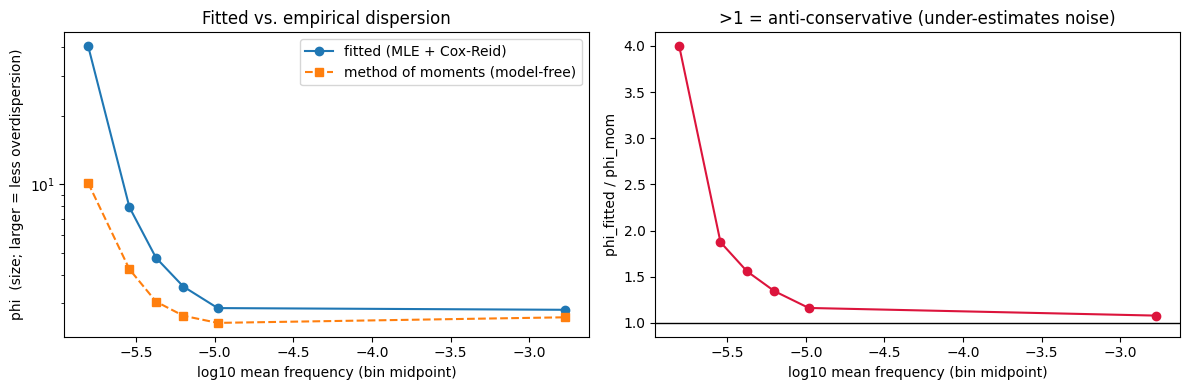

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

mid = (cmp1['lo'] + cmp1['hi']) / 2
ax[0].plot(mid, cmp1['phi_fitted'], 'o-', label='fitted (MLE + Cox-Reid)')
ax[0].plot(mid, cmp1['phi_mom'],    's--', label='method of moments (model-free)')
ax[0].set_xlabel('log10 mean frequency (bin midpoint)')
ax[0].set_ylabel('phi  (size; larger = less overdispersion)')
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title('Fitted vs. empirical dispersion')

ax[1].axhline(1.0, color='k', lw=1)
ax[1].plot(mid, cmp1['ratio_fitted_over_mom'], 'o-', color='crimson')
ax[1].set_xlabel('log10 mean frequency (bin midpoint)')
ax[1].set_ylabel('phi_fitted / phi_mom')
ax[1].set_title('>1 = anti-conservative (under-estimates noise)')

plt.tight_layout(); plt.show()

**Finer-grained version** - the 6 bins may be too coarse to see the shape the step
function is failing to track. This refits MoM phi on many narrow slices (no MLE, so it is
cheap) and overlays the fitted step function. If the MoM curve is smooth and the step
function cuts across it, diagnostic (1) is confirmed.

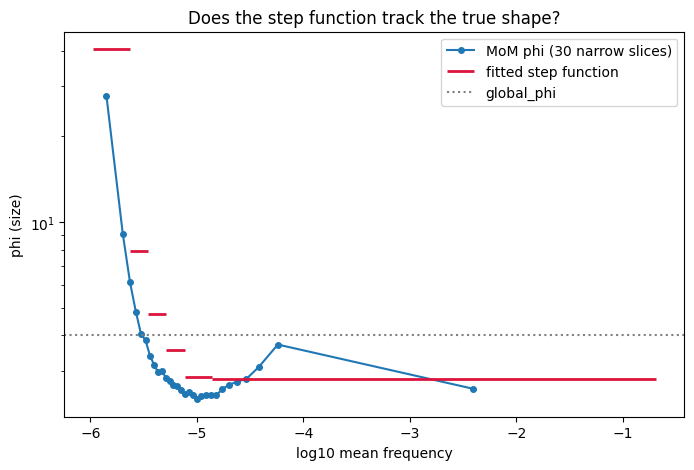

In [9]:

n_fine = 30
fine_edges = np.quantile(S['log_mf'], np.linspace(0, 1, n_fine + 1))
fine_edges = np.unique(fine_edges)
fine_idx = np.clip(np.digitize(S['log_mf'], fine_edges[1:-1]), 0, len(fine_edges) - 2)

fx, fy, fn = [], [], []
for b in range(len(fine_edges) - 1):
    g = S[fine_idx == b]
    if len(g) < 20:
        continue
    fx.append((fine_edges[b] + fine_edges[b + 1]) / 2)
    fy.append(mom_phi(g['x'], g['mu']))
    fn.append(len(g))

plt.figure(figsize=(8, 5))
plt.plot(fx, fy, 'o-', ms=4, label=f'MoM phi ({n_fine} narrow slices)')
for b in range(actual_bins):
    p = model['phi_per_bin'][b]
    if p is not None:
        plt.hlines(p, edges[b], edges[b + 1], color='crimson', lw=2,
                   label='fitted step function' if b == 0 else None)
plt.axhline(model['global_phi'], color='grey', ls=':', label='global_phi')
plt.xlabel('log10 mean frequency'); plt.ylabel('phi (size)')
plt.yscale('log'); plt.legend(); plt.title('Does the step function track the true shape?')
plt.show()

## Cell 3 - trended-phi test runner

`nb_glm_trajectory_test` takes a **scalar** phi. This wrapper looks up each clonotype's
trended phi and groups clonotypes by phi value so the existing function is reused
unchanged (at most `N_BINS` calls, not one per clonotype).

In [21]:
def run_trended_test(test_df, model, min_obs=None):
    """Run nb_glm_trajectory_test with per-clonotype trended phi."""
    min_obs = MIN_OBS if min_obs is None else min_obs
    S_t = clono_summary(test_df, min_obs=min_obs)
    if S_t.empty:
        return pd.DataFrame()

    S_t['phi'] = [phi_for_freq(model, f) for f in S_t['mean_freq']]
    key = S_t[['patient', 'clono', 'phi', 'mean_freq', 'log_mf']]

    d = test_df.merge(key[['patient', 'clono', 'phi']], on=['patient', 'clono'], how='inner')

    out = []
    for phi_val, chunk in d.groupby('phi'):
        r = nb_glm_trajectory_test(
            chunk.drop(columns=['phi']), dispersion=float(phi_val),
            count_col=COUNT_COL, time_col=TIME_COL, min_obs=min_obs, test='lrt',
        )
        if len(r):
            r['phi_used'] = float(phi_val)
            out.append(r)

    if not out:
        return pd.DataFrame()

    res = pd.concat(out, ignore_index=True)
    return res.merge(key[['patient', 'clono', 'mean_freq', 'log_mf']],
                     on=['patient', 'clono'], how='left')

## Cell 4 - Diagnostic (2): leave-one-donor-out FPR

Fit the trend on all donors **except** one, test on the held-out donor. This is also the
check for whether your original FPR table was in-sample: if these LODO numbers are
materially worse than the table you showed, the original was self-referential.

May take a few minutes. Set `SUBSAMPLE` to cap clonotypes per donor while iterating.

In [13]:

SUBSAMPLE = None   # e.g. 20000 to cap clonotypes per held-out donor; None = all

donors = sorted(HEALTHY[DONOR_COL].unique())
lodo = []

for d in donors:
    train = HEALTHY[HEALTHY[DONOR_COL] != d]
    test  = HEALTHY[HEALTHY[DONOR_COL] == d]

    if SUBSAMPLE is not None:
        keep = (test[['patient', 'clono']].drop_duplicates()
                    .sample(min(SUBSAMPLE, test['clono'].nunique()), random_state=0))
        test = test.merge(keep, on=['patient', 'clono'], how='inner')

    m = fit_nb_dispersion_trended(train, count_col=COUNT_COL, n_bins=N_BINS, min_obs=2)
    r = run_trended_test(test, m)
    if len(r):
        r['held_out'] = d
        lodo.append(r)
    print(f"{d}: trained on {len(donors)-1} donors, tested {len(r)} clonotypes")

LODO = pd.concat(lodo, ignore_index=True)
LODO['sig']     = LODO['p_value'] < ALPHA
LODO['sig_exp'] = LODO['sig'] & (LODO['direction'] == 'expansion')
LODO['sig_con'] = LODO['sig'] & (LODO['direction'] == 'contraction')
LODO['freq_bin'] = pd.cut(LODO['log_mf'], bins=edges, include_lowest=True)

print(f"\ntotal tested: {len(LODO)}   overall FPR: {LODO['sig'].mean():.3f}   (nominal {ALPHA})")

HD106_SEQTR: trained on 5 donors, tested 22689 clonotypes
HD197_SEQTR: trained on 5 donors, tested 29987 clonotypes
HDBR01_SEQTR_ReSeq: trained on 5 donors, tested 12158 clonotypes
HDBR02_SEQTR_ReSeq: trained on 5 donors, tested 10198 clonotypes
HDBR03_SEQTR_ReSeq: trained on 5 donors, tested 31930 clonotypes
HDBR06_SEQTR_ReSeq: trained on 5 donors, tested 6775 clonotypes

total tested: 113737   overall FPR: 0.126   (nominal 0.05)


In [14]:

# --- pooled table (comparable to the one you already have) ---
pooled = (LODO.groupby('freq_bin', observed=True)
              .agg(n=('p_value', 'size'),
                   FPR=('sig', 'mean'),
                   sig_exp=('sig_exp', 'sum'),
                   sig_con=('sig_con', 'sum'))
              .round(3))
print("POOLED (LODO):"); display(pooled)

# --- the actual diagnostic: same table, split by held-out donor ---
per_donor = (LODO.groupby(['held_out', 'freq_bin'], observed=True)
                 .agg(n=('p_value', 'size'),
                      FPR=('sig', 'mean'),
                      sig_exp=('sig_exp', 'sum'),
                      sig_con=('sig_con', 'sum'))
                 .round(3))
print("\nPER HELD-OUT DONOR:"); display(per_donor)

# --- spread across donors within each bin: the decisive number ---
fpr_mat = LODO.pivot_table(index='freq_bin', columns='held_out',
                           values='sig', aggfunc='mean', observed=True).round(3)
fpr_mat['spread'] = (fpr_mat.max(axis=1) - fpr_mat.min(axis=1)).round(3)
fpr_mat['mean']   = fpr_mat.drop(columns='spread').mean(axis=1).round(3)
print("\nFPR by bin x held-out donor:"); display(fpr_mat)

POOLED (LODO):


,n,FPR,sig_exp,sig_con
freq_bin,,,,
"(-5.981000000000001, -5.63]",9178,0.147,806,542
"(-5.63, -5.455]",14062,0.144,1155,876
"(-5.455, -5.292]",16559,0.136,1273,974
"(-5.292, -5.108]",19679,0.126,1334,1140
"(-5.108, -4.854]",23073,0.123,1361,1467
"(-4.854, -0.689]",31186,0.110,1436,1981



PER HELD-OUT DONOR:


n    FPR  sig_exp  sig_con
held_out           freq_bin                                                  
HD106_SEQTR        (-5.981000000000001, -5.63]  1974  0.211      299      118
                   (-5.63, -5.455]              3307  0.158      309      213
                   (-5.455, -5.292]             3950  0.142      317      242
                   (-5.292, -5.108]             4396  0.125      270      278
                   (-5.108, -4.854]             4480  0.118      246      284
                   (-4.854, -0.689]             4582  0.064      147      147
HD197_SEQTR        (-5.981000000000001, -5.63]  3250  0.138      178      269
                   (-5.63, -5.455]              5150  0.134      322      368
                   (-5.455, -5.292]             5515  0.117      324      322
                   (-5.292, -5.108]             5519  0.095      289      237
                   (-5.108, -4.854]             5083  0.062      186      129
                   (-4.854, -0.689]             5470  0.029       85       73
HDBR01_SEQTR_ReSeq (-5.981000000000001, -5.63]   540  0.217       53       64
                   (-5.63, -5.455]               897  0.235      100      111
                   (-5.455, -5.292]             1238  0.212      131      132
                   (-5.292, -5.108]             1877  0.182      164      177
                   (-5.108, -4.854]             3029  0.169      230      283
                   (-4.854, -0.689]             4577  0.157      332      388
HDBR02_SEQTR_ReSeq (-5.981000000000001, -5.63]   655  0.105       21       48
                   (-5.63, -5.455]               858  0.099       18       67
                   (-5.455, -5.292]             1049  0.092       20       77
                   (-5.292, -5.108]             1507  0.078       45       73
                   (-5.108, -4.854]             2121  0.061       47       83
                   (-4.854, -0.689]             4008  0.028       60       54
HDBR03_SEQTR_ReSeq (-5.981000000000001, -5.63]  2458  0.103      224       29
                   (-5.63, -5.455]              3518  0.133      372       97
                   (-5.455, -5.292]             4350  0.140      437      174
                   (-5.292, -5.108]             5708  0.144      497      325
                   (-5.108, -4.854]             7133  0.157      538      579
                   (-4.854, -0.689]             8763  0.167      470      994
HDBR06_SEQTR_ReSeq (-5.981000000000001, -5.63]   301  0.150       31       14
                   (-5.63, -5.455]               332  0.163       34       20
                   (-5.455, -5.292]              457  0.155       44       27
                   (-5.292, -5.108]              672  0.177       69       50
                   (-5.108, -4.854]             1227  0.182      114      109
                   (-4.854, -0.689]             3786  0.176      342      325


FPR by bin x held-out donor:


held_out,HD106_SEQTR,HD197_SEQTR,HDBR01_SEQTR_ReSeq,HDBR02_SEQTR_ReSeq,HDBR03_SEQTR_ReSeq,HDBR06_SEQTR_ReSeq,spread,mean
freq_bin,,,,,,,,
"(-5.981000000000001, -5.63]",0.211,0.138,0.217,0.105,0.103,0.150,0.114,0.154
"(-5.63, -5.455]",0.158,0.134,0.235,0.099,0.133,0.163,0.136,0.154
"(-5.455, -5.292]",0.142,0.117,0.212,0.092,0.140,0.155,0.120,0.143
"(-5.292, -5.108]",0.125,0.095,0.182,0.078,0.144,0.177,0.104,0.133
"(-5.108, -4.854]",0.118,0.062,0.169,0.061,0.157,0.182,0.121,0.125
"(-4.854, -0.689]",0.064,0.029,0.157,0.028,0.167,0.176,0.148,0.104


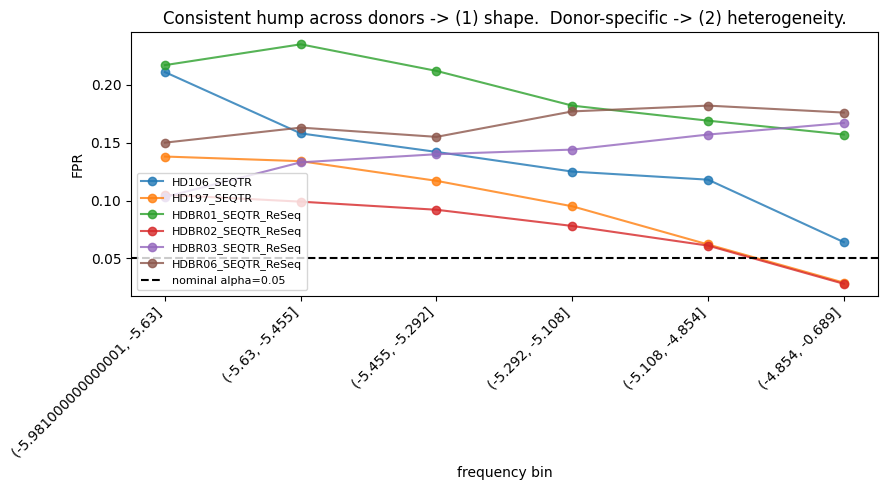

In [15]:

plt.figure(figsize=(9, 5))
for d in donors:
    sub = fpr_mat[d] if d in fpr_mat.columns else None
    if sub is None:
        continue
    plt.plot(range(len(sub)), sub.values, 'o-', label=d, alpha=.8)
plt.axhline(ALPHA, color='k', ls='--', label=f'nominal alpha={ALPHA}')
plt.xticks(range(len(fpr_mat)), [str(i) for i in fpr_mat.index], rotation=45, ha='right')
plt.ylabel('FPR'); plt.xlabel('frequency bin')
plt.title('Consistent hump across donors -> (1) shape.  Donor-specific -> (2) heterogeneity.')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**Decision rule.** Compare the `spread` column against the `mean` column in the bins
that are inflated:

- `spread` small relative to the excess over alpha -> every donor shows the same hump
  -> **diagnostic (1)**, trend shape. Smoothing + tagwise shrinkage should fix it.
- `spread` comparable to or larger than the excess -> the inflation is donor-specific
  -> **diagnostic (2)**, between-donor heterogeneity. No amount of smoothing the shared
  curve fixes this; you need the per-donor scale multiplier with partial pooling.

With only a handful of donors, note that each LODO fold retrains on `n_donors - 1`
donors, so a single atypical donor moves both the trend *and* its own held-out FPR.

## Cell 5 - Diagnostic (3): is the chi2 LRT anti-conservative at small n?

The LRT's chi2_1 reference is asymptotic in the number of timepoints. With 3-6 points it
can be anti-conservative **regardless of whether phi is right**. If FPR tracks `n_obs`,
some of the inflation is not a dispersion problem at all.

In [16]:

by_n = (LODO.groupby('n_obs')
            .agg(n=('p_value', 'size'),
                 FPR=('sig', 'mean'),
                 sig_exp=('sig_exp', 'sum'),
                 sig_con=('sig_con', 'sum'),
                 median_p=('p_value', 'median'))
            .round(3))
print("FPR by number of timepoints:"); display(by_n)

# Is the abundance effect just n_obs in disguise? Do bins differ in n_obs?
print("\nmean n_obs per frequency bin:")
display(LODO.groupby('freq_bin', observed=True)['n_obs'].agg(['mean', 'median', 'size']).round(2))

FPR by number of timepoints:


,n,FPR,sig_exp,sig_con,median_p
n_obs,,,,,
3,64691,0.141,4651,4489,0.375
4,40127,0.103,2189,1934,0.455
5,8919,0.121,525,557,0.396



mean n_obs per frequency bin:


,mean,median,size
freq_bin,,,
"(-5.981000000000001, -5.63]",3.22,3.0,9178
"(-5.63, -5.455]",3.31,3.0,14062
"(-5.455, -5.292]",3.38,3.0,16559
"(-5.292, -5.108]",3.46,3.0,19679
"(-5.108, -4.854]",3.56,3.0,23073
"(-4.854, -0.689]",3.74,4.0,31186


In [17]:

# The disentangler: FPR as a function of BOTH. If the abundance gradient survives
# within each n_obs stratum, it is genuinely a dispersion-model problem.
cross = LODO.pivot_table(index='freq_bin', columns='n_obs',
                         values='sig', aggfunc='mean', observed=True).round(3)
counts = LODO.pivot_table(index='freq_bin', columns='n_obs',
                          values='sig', aggfunc='size', observed=True)
print("FPR by freq_bin x n_obs  (cells with <200 obs are unstable):")
display(cross.where(counts >= 200))
print("\ncell counts:"); display(counts)

FPR by freq_bin x n_obs  (cells with <200 obs are unstable):


n_obs,3,4,5
freq_bin,,,
"(-5.981000000000001, -5.63]",0.142,0.165,NaN
"(-5.63, -5.455]",0.147,0.139,0.133
"(-5.455, -5.292]",0.141,0.122,0.150
"(-5.292, -5.108]",0.137,0.108,0.123
"(-5.108, -4.854]",0.141,0.098,0.121
"(-4.854, -0.689]",0.141,0.078,0.114



cell counts:


n_obs,3,4,5
freq_bin,,,
"(-5.981000000000001, -5.63]",7283,1736,159
"(-5.63, -5.455]",10049,3600,413
"(-5.455, -5.292]",10850,5068,641
"(-5.292, -5.108]",11590,7048,1041
"(-5.108, -4.854]",11944,9242,1887
"(-4.854, -0.689]",12975,13433,4778


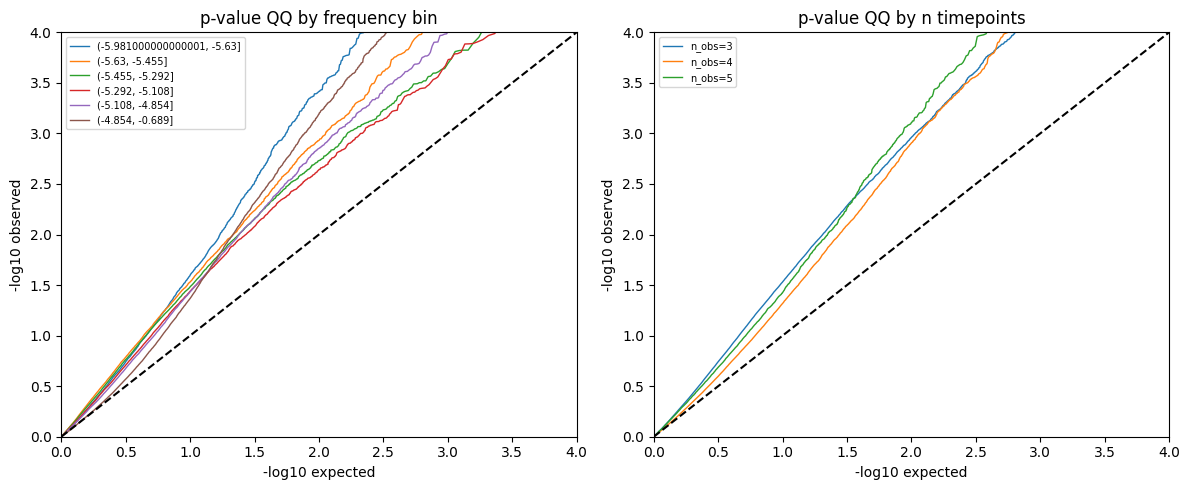

In [18]:

# p-value uniformity: under a correct null p ~ Uniform(0,1). A QQ plot shows *where*
# the null fails - whole-curve departure vs. only the extreme tail.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for b, g in LODO.groupby('freq_bin', observed=True):
    p = np.sort(g['p_value'].dropna().values)
    if len(p) < 100:
        continue
    exp = (np.arange(1, len(p) + 1) - 0.5) / len(p)
    ax[0].plot(-np.log10(exp), -np.log10(p), lw=1, label=str(b))
lim = 4
ax[0].plot([0, lim], [0, lim], 'k--')
ax[0].set_xlim(0, lim); ax[0].set_ylim(0, lim)
ax[0].set_xlabel('-log10 expected'); ax[0].set_ylabel('-log10 observed')
ax[0].set_title('p-value QQ by frequency bin'); ax[0].legend(fontsize=7)

for nb, g in LODO.groupby('n_obs'):
    p = np.sort(g['p_value'].dropna().values)
    if len(p) < 100:
        continue
    exp = (np.arange(1, len(p) + 1) - 0.5) / len(p)
    ax[1].plot(-np.log10(exp), -np.log10(p), lw=1, label=f'n_obs={nb}')
ax[1].plot([0, lim], [0, lim], 'k--')
ax[1].set_xlim(0, lim); ax[1].set_ylim(0, lim)
ax[1].set_xlabel('-log10 expected'); ax[1].set_ylabel('-log10 observed')
ax[1].set_title('p-value QQ by n timepoints'); ax[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

## Cell 6 - summary

One place to read off which mechanism dominates.

In [19]:

print("=" * 66)
print("DIAGNOSTIC (1)  trend shape / binning")
print("=" * 66)
MOM_BASELINE = 1.1   # MoM reads ~10% high even under a correct model
bad = cmp1[cmp1['ratio_fitted_over_mom'] > 1.25 * MOM_BASELINE]
print(f"  bins anti-conservative vs. MoM baseline {MOM_BASELINE}: {len(bad)}/{len(cmp1)}")
print(f"  ratio range across bins: {cmp1['ratio_fitted_over_mom'].min():.2f}"
      f" - {cmp1['ratio_fitted_over_mom'].max():.2f}"
      f"  (variation across bins matters more than the level)")
if len(bad):
    print(bad[['bin', 'lo', 'hi', 'n_clones', 'phi_fitted', 'phi_mom',
               'ratio_fitted_over_mom']].to_string(index=False))
print(f"  bins using global_phi fallback : {int(cmp1['used_fallback'].sum())}")
print(f"  widest bin / narrowest bin     : {cmp1['width'].max() / cmp1['width'].min():.1f}x")

print()
print("=" * 66)
print("DIAGNOSTIC (2)  between-donor heterogeneity")
print("=" * 66)
exc = (fpr_mat['mean'] - ALPHA).clip(lower=0)
rel = (fpr_mat['spread'] / exc.replace(0, np.nan)).round(2)
print("  per-bin: mean FPR, donor spread, spread/excess")
print(pd.DataFrame({'mean_FPR': fpr_mat['mean'], 'spread': fpr_mat['spread'],
                    'spread_over_excess': rel}).to_string())
print("  spread_over_excess << 1  -> shared shape problem (1)")
print("  spread_over_excess ~> 1  -> donor heterogeneity (2)")

print()
print("=" * 66)
print("DIAGNOSTIC (3)  small-sample LRT")
print("=" * 66)
print(by_n[['n', 'FPR', 'median_p']].to_string())
print("  median_p should be ~0.5 under a correct null.")
print("  FPR falling as n_obs rises -> finite-sample LRT problem, not phi.")

DIAGNOSTIC (1)  trend shape / binning
  bins anti-conservative vs. MoM baseline 1.1: 3/6
  ratio range across bins: 1.08 - 4.00  (variation across bins matters more than the level)
 bin     lo     hi  n_clones  phi_fitted   phi_mom  ratio_fitted_over_mom
   0 -5.980 -5.630      9178   40.475505 10.126627               3.996939
   1 -5.630 -5.455     14062    7.921692  4.227196               1.873983
   2 -5.455 -5.292     16544    4.748383  3.048090               1.557822
  bins using global_phi fallback : 0
  widest bin / narrowest bin     : 25.6x

DIAGNOSTIC (2)  between-donor heterogeneity
  per-bin: mean FPR, donor spread, spread/excess
                             mean_FPR  spread  spread_over_excess
freq_bin                                                         
(-5.981000000000001, -5.63]     0.154   0.114                1.10
(-5.63, -5.455]                 0.154   0.136                1.31
(-5.455, -5.292]                0.143   0.120                1.29
(-5.292, -5.108]     